# **OLA BUSINESS CASE STUDY**

## **PROBLEM STATEMENT**

---

Ola is facing a significant challenge in retaining drivers, with many drivers discontinuing their association due to fluctuating income, inconsistent performance incentives, and competitive alternatives. This high driver attrition increases operational costs, as acquiring new drivers is more expensive than retaining existing ones.

The dataset consists of monthly time-series data for each driver, capturing their demographics, tenure, and performance over time. Since multiple records exist per driver, the data must be aggregated at the driver level to enable meaningful modeling.

The objective of this project is to build a predictive model that can identify whether a driver is likely to leave the platform, based on:
- Demographic attributes (age, gender, city, education)
- Tenure-related information (date of joining, last working date)
- Performance metrics (monthly income, total business value, quarterly rating, grade)
- Since the dataset does not directly provide the target variable, driver attrition will be inferred using the presence of a last working date.

This problem is formulated as a binary classification task:
- 1: Driver has left the platform
- 0: Driver is active

By predicting driver attrition in advance, Ola can:
- Identify at-risk drivers early
- Implement targeted retention strategies
- Optimize driver acquisition costs
- Improve overall platform stability

To solve this, we will apply ensemble learning techniques (**BAGGING & BOOSTING**) along with appropriate data preprocessing, feature engineering, and handling of class imbalance.

## **MODULES' IMPORT**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **DATA UPLOAD**

In [ ]:
!wget https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/492/original/ola_driver_scaler.csv

--2026-03-17 12:54:50--  https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/492/original/ola_driver_scaler.csv
Resolving d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)... 3.170.7.158, 3.170.7.168, 3.170.7.76, ...
Connecting to d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)|3.170.7.158|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1127673 (1.1M) [text/plain]
Saving to: ‘ola_driver_scaler.csv.9’

ola_driver_scaler.c 100%[===================>]   1.08M  --.-KB/s    in 0.009s  

2026-03-17 12:54:50 (114 MB/s) - ‘ola_driver_scaler.csv.9’ saved [1127673/1127673]



In [ ]:
df = pd.read_csv('ola_driver_scaler.csv')
df = df.drop('Unnamed: 0', axis=1)
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


## **EXPLORATORY DATA ANALYSIS (EDA):**

In [ ]:
df.shape

(19104, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MMM-YY                19104 non-null  object 
 1   Driver_ID             19104 non-null  int64  
 2   Age                   19043 non-null  float64
 3   Gender                19052 non-null  float64
 4   City                  19104 non-null  object 
 5   Education_Level       19104 non-null  int64  
 6   Income                19104 non-null  int64  
 7   Dateofjoining         19104 non-null  object 
 8   LastWorkingDate       1616 non-null   object 
 9   Joining Designation   19104 non-null  int64  
 10  Grade                 19104 non-null  int64  
 11  Total Business Value  19104 non-null  int64  
 12  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(7), object(4)
memory usage: 1.9+ MB


**Target Variable: attrition**

It represents whether a driver has discontinued their association with the platform and indicates if the driver has left or is still active.

This variable is derived using the **LastWorkingDate** column, where the presence of a date signifies that the driver has exited the platform.

The target variable is converted into a binary format for classification modeling:
- 1: Driver has left (attrition)
- 0: Driver is active

In [ ]:
df.isnull().sum()

,0
MMM-YY,0
Driver_ID,0
Age,61
Gender,52
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,17488
Joining Designation,0


### **STATISTICAL SUMMARY OF NUMERIC VARIABLES**

In [ ]:
df.describe()

,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
count,19104.000000,19043.000000,19052.000000,19104.000000,19104.000000,19104.000000,19104.000000,1.910400e+04,19104.000000
mean,1415.591133,34.668435,0.418749,1.021671,65652.025126,1.690536,2.252670,5.716621e+05,2.008899
std,810.705321,6.257912,0.493367,0.800167,30914.515344,0.836984,1.026512,1.128312e+06,1.009832
min,1.000000,21.000000,0.000000,0.000000,10747.000000,1.000000,1.000000,-6.000000e+06,1.000000
25%,710.000000,30.000000,0.000000,0.000000,42383.000000,1.000000,1.000000,0.000000e+00,1.000000
50%,1417.000000,34.000000,0.000000,1.000000,60087.000000,1.000000,2.000000,2.500000e+05,2.000000
75%,2137.000000,39.000000,1.000000,2.000000,83969.000000,2.000000,3.000000,6.997000e+05,3.000000
max,2788.000000,58.000000,1.000000,2.000000,188418.000000,5.000000,5.000000,3.374772e+07,4.000000


- Dataset contains **monthly records** for drivers across **2019–2020**
- Multiple entries per driver indicates **time-series nature**
- Presence of **missing values**, especially in **LastWorkingDate**
- Mix of categorical (City, Gender) and numerical variables

### **TARGET VARIABLE CREATION & DISTRIBUTION**

In [ ]:
df['attrition'] = df['LastWorkingDate'].notnull().astype(int)

df['attrition'].value_counts(normalize=True)

,proportion
attrition,
0,0.91541
1,0.08459


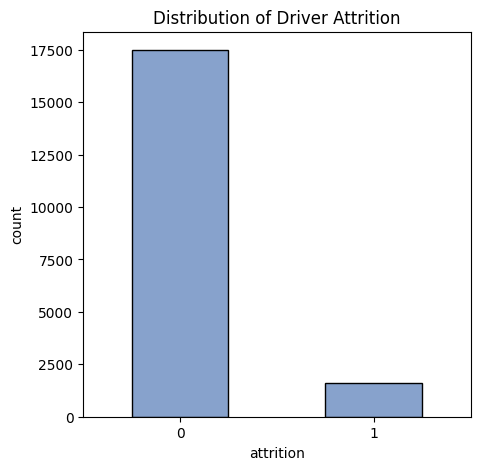

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(x='attrition', data=df, width=0.5, edgecolor='black', color='#7ba0d8')
plt.title("Distribution of Driver Attrition")
plt.show()

- The distribution of the target variable indicates a significant **class imbalance** in the dataset. Approximately 91.5% of drivers are active (attrition = 0), while only about 8.5% of drivers have left the platform (attrition = 1).

- This imbalance reflects real-world business scenarios where most drivers remain active, but accurately identifying the minority class (drivers who leave) is critical for proactive retention strategies.

- This imbalance suggests that the dataset is **heavily skewed** toward the majority class (active drivers). As a result, a **classification model** trained on this data **may become biased** toward predicting the majority class, leading to poor performance in identifying drivers who are likely to leave.

- To address this issue, appropriate techniques such as **SMOTE** (Synthetic Minority Oversampling Technique) will be applied during the preprocessing stage to **balance the classes** and **improve model performance**.

### **UNIVARIATE ANALYSIS**

#### **Categorical / Discrete Variables**

- **Gender**

In [ ]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0]).astype(int)

Gender
0    11126
1     7978
Name: count, dtype: int64 

Gender
0    58.239112
1    41.760888
Name: proportion, dtype: float64 



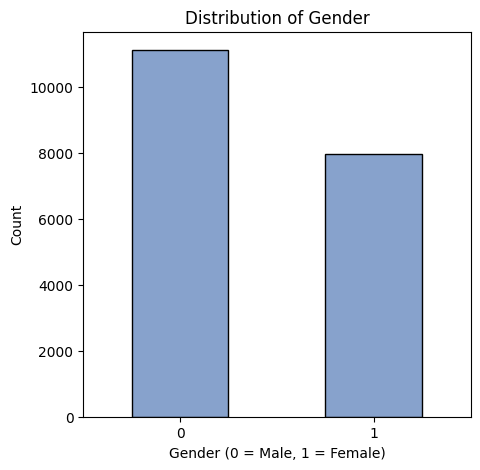

In [ ]:
print(df['Gender'].value_counts(),'\n')
print(df['Gender'].value_counts(normalize=True)*100,'\n')

plt.figure(figsize=(5,5))
sns.countplot(x='Gender', data=df, width=0.5, edgecolor='black', color='#7ba0d8')
plt.title("Distribution of Gender")
plt.xlabel("Gender (0 = Male, 1 = Female)")
plt.ylabel("Count")
plt.show()

- The dataset shows a **male-dominated driver base**, with 11,126 male drivers (≈58%) and 7,978 female drivers (≈42%).

- Although both genders are represented, there is a noticeable imbalance in favor of male drivers, indicating **relatively lower participation of female drivers on the platform**. This skew in gender distribution may influence driver behavior patterns and should be considered during further analysis.

- **City**

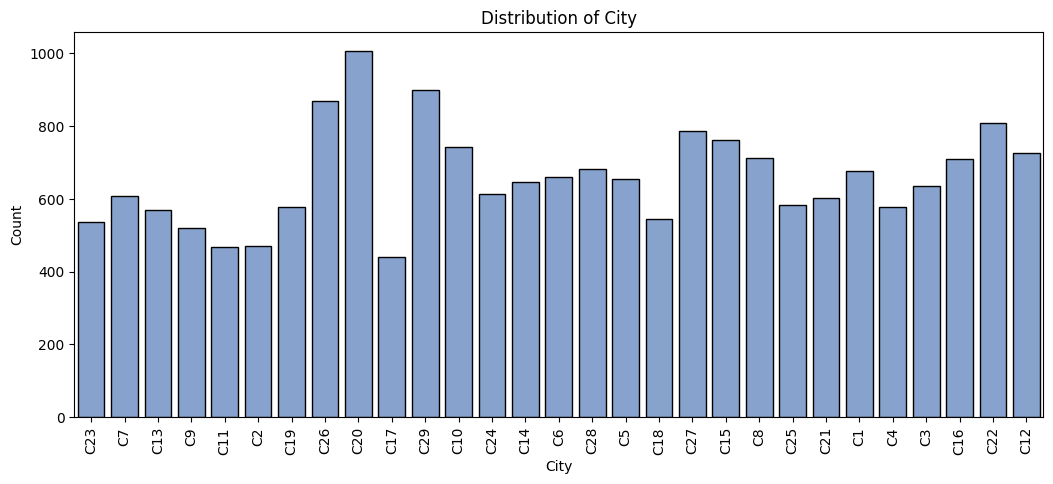

In [ ]:
plt.figure(figsize=(12.5,5))
sns.countplot(x='City', data=df, edgecolor='black', color='#7ba0d8')
plt.title("Distribution of City")
plt.xlabel("City")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()

- The distribution of drivers across cities appears to be **relatively dispersed**, with all cities contributing a substantial number of drivers. However, there is moderate variation, with certain cities (e.g., those with counts approaching ~1000) having noticeably higher representation compared to others (around ~450–600).
- This indicates that while the platform has a **broad geographical presence**, driver concentration is not uniform across cities, suggesting possible differences in demand, market size, or operational focus across locations.

- **Education Level**

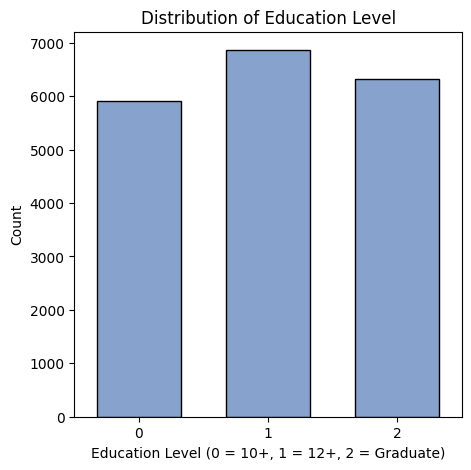

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(x='Education_Level', data=df, edgecolor='black', color='#7ba0d8', width=0.65)
plt.title("Distribution of Education Level")
plt.xlabel("Education Level (0 = 10+, 1 = 12+, 2 = Graduate)")
plt.ylabel("Count")
plt.show()

- The distribution of education levels is **fairly balanced** across categories, with a slightly higher concentration of drivers in the 12+ category, followed by graduates, and then 10+.
- This indicates that most drivers possess at least a moderate level of education, with no extreme skew toward any single category. The relatively even spread suggests that **education level may have a limited standalone impact** but could still contribute when combined with other features in predicting attrition.

- **Quarterly Rating**

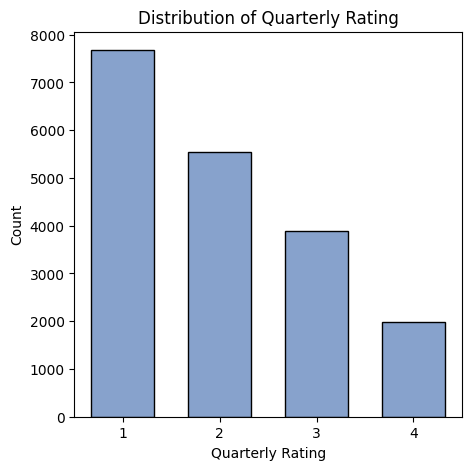

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(x='Quarterly Rating', data=df, edgecolor='black', color='#7ba0d8', width=0.65)
plt.title("Distribution of Quarterly Rating")
plt.xlabel("Quarterly Rating")
plt.ylabel("Count")
plt.show()

- The distribution of quarterly ratings is **skewed toward lower values**, with the highest number of drivers receiving a rating of 1, followed by 2, while significantly fewer drivers fall into higher rating categories (3 and 4).
- This indicates that **a large proportion of drivers are rated below average**, suggesting **potential performance challenges within the driver base**. The declining trend as ratings increase highlights that high-performing drivers are relatively fewer, which may have implications for customer satisfaction and driver retention.

#### **Numeric / Continuous Variables**

- **Age**

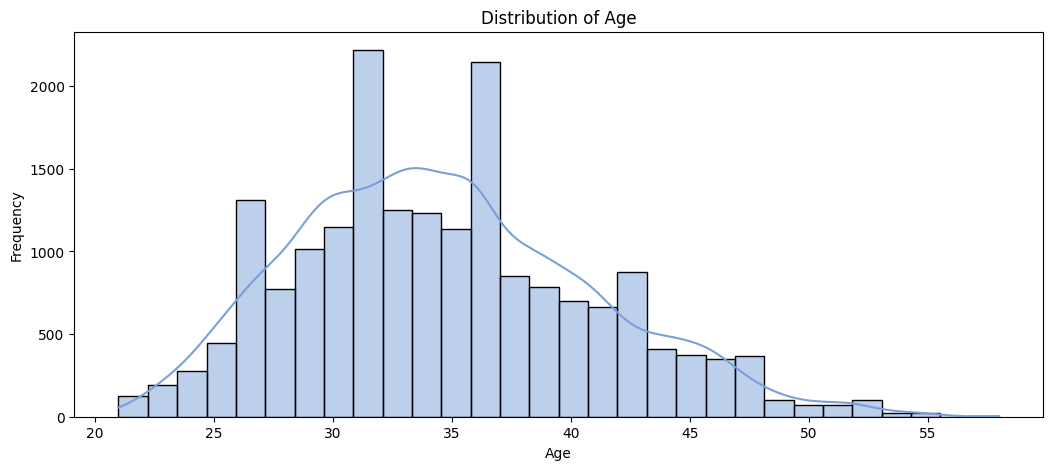

In [ ]:
plt.figure(figsize=(12.5,5))
sns.histplot(df['Age'], bins=30, kde=True, edgecolor='black', color='#7ba0d8')
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

- The age distribution of drivers is **approximately bell-shaped** with a slight right skew, with the majority of drivers concentrated in the age range of 28 to 38 years. The **peak appears around the early 30s**, indicating that most drivers belong to a young to middle-aged demographic.
- There are relatively fewer drivers in the higher age brackets (above 45), and very few beyond 50, suggesting that **the platform is primarily driven by a younger workforce**.

- **Income**

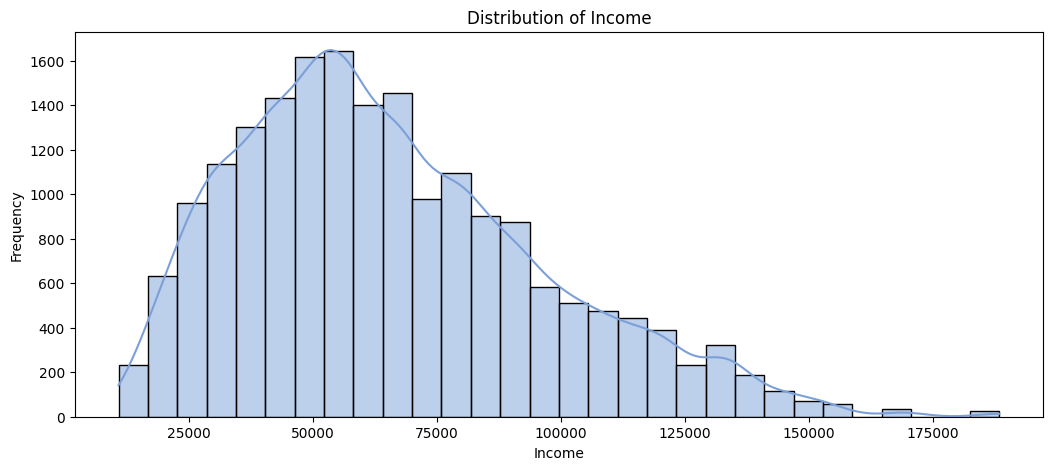

In [ ]:
plt.figure(figsize=(12.5,5))
sns.histplot(df['Income'], bins=30, kde=True, edgecolor='black', color='#7ba0d8')
plt.title("Distribution of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

- The income distribution is positively skewed (**right-skewed**), with the majority of drivers earning in the range of approximately ₹30,000 to ₹80,000, and a peak around ₹50,000–₹60,000.
- A long tail is observed toward higher income levels, indicating that a **smaller proportion of drivers earn significantly higher incomes** (above ₹100,000). This suggests the presence of **income disparity**, where most drivers earn moderate incomes while a few high performers earn substantially more.

- **Total Business Value**

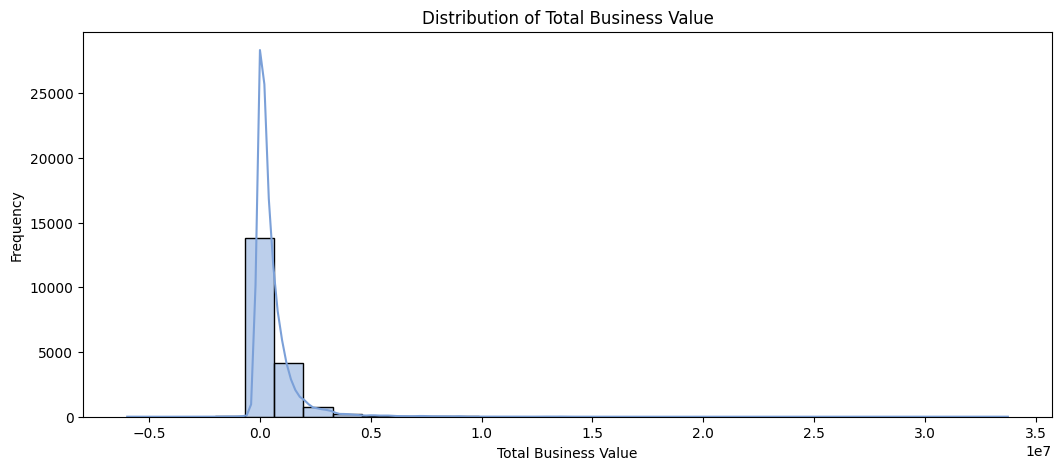

In [ ]:
plt.figure(figsize=(12.5,5))
sns.histplot(df['Total Business Value'], bins=30, kde=True, edgecolor='black', color='#7ba0d8')
plt.title("Distribution of Total Business Value")
plt.xlabel("Total Business Value")
plt.ylabel("Frequency")
plt.show()

- The distribution of total business value is **highly positively skewed**, with a large concentration of values clustered close to zero, and a long tail extending toward very high values.
- There are **also negative values** present, indicating cancellations, refunds, or adjustments. The presence of extreme high values suggests **outliers**, where a small number of drivers contribute disproportionately large business volumes.
- Overall, this reflects **high variability in driver performance**, with most drivers generating low to moderate business value and a few high-performing drivers driving significant revenue.

### **BIVARIATE ANALYSIS**

- **Income vs Attrition**

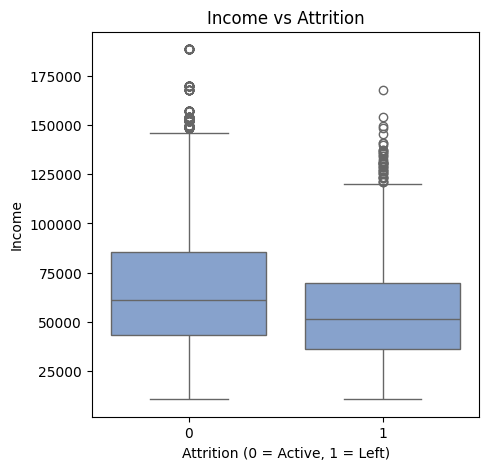

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(x='attrition', y='Income', data=df, color='#7ba0d8')
plt.title("Income vs Attrition")
plt.xlabel("Attrition (0 = Active, 1 = Left)")
plt.ylabel("Income")
plt.show()

- The boxplot indicates that **drivers who have left** the platform (attrition = 1) tend to have **relatively lower median income** compared to those who remain active (attrition = 0).
- **Active drivers** show a higher median income and a **wider upper range**, suggesting that **higher-earning drivers are more likely to stay** with the platform. In contrast, drivers with lower income levels appear more prone to attrition.
- This highlights income as a key factor influencing driver retention, where **better earnings are associated with increased likelihood of staying** on the platform.

- **Rating vs Attrition**

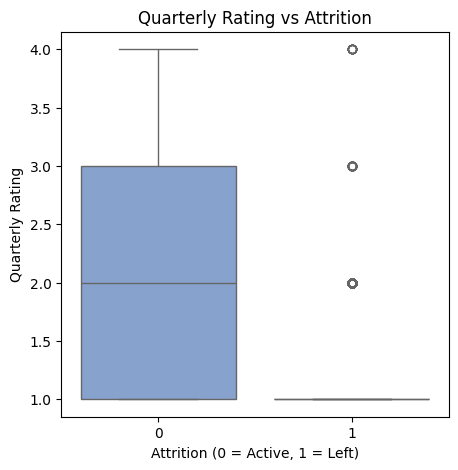

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(x='attrition', y='Quarterly Rating', data=df, color='#7ba0d8')
plt.title("Quarterly Rating vs Attrition")
plt.xlabel("Attrition (0 = Active, 1 = Left)")
plt.ylabel("Quarterly Rating")
plt.show()

- The boxplot shows that **drivers who have left** the platform (attrition = 1) are **predominantly associated with the lowest rating** (1), with very limited variation. In contrast, active drivers (attrition = 0) exhibit a wider distribution of ratings, with a higher median around 2 and values extending up to 4.
- This indicates that **low-performing drivers are significantly more likely to leave**, while drivers with better ratings tend to remain active. Hence, quarterly rating is a strong indicator of attrition, with poor performance closely linked to driver exit.

- **Total Business Value vs Attrition**

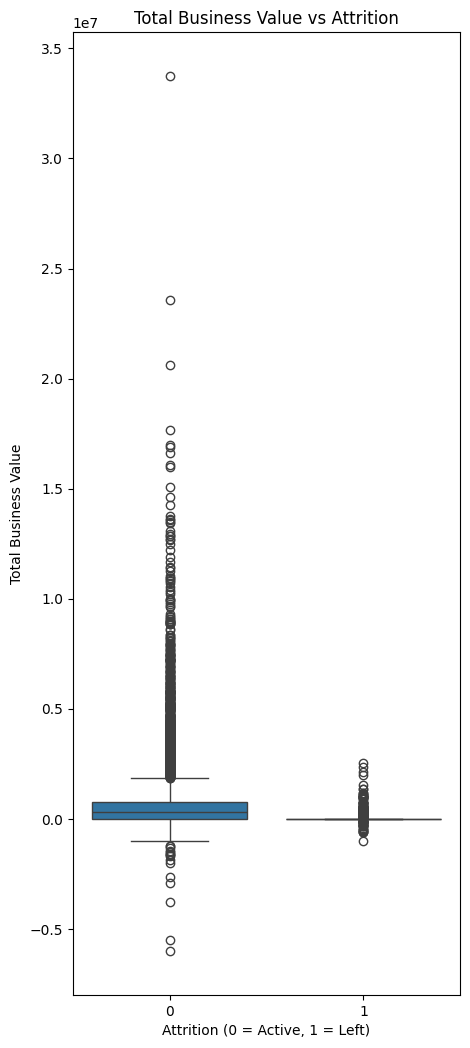

In [ ]:
plt.figure(figsize=(5,12.5))
sns.boxplot(x='attrition', y='Total Business Value', data=df)
plt.title("Total Business Value vs Attrition")
plt.xlabel("Attrition (0 = Active, 1 = Left)")
plt.ylabel("Total Business Value")
plt.show()

- The boxplot shows that **drivers who remain active** (attrition = 0) exhibit a much wider spread and significantly **higher upper range of total business value, including several high-value outliers**. In contrast, drivers who have left (attrition = 1) are largely concentrated around low or near-zero business values, with minimal variation.
- Additionally, **both groups contain some negative values**, indicating cancellations or adjustments; however, these are **more tightly clustered among drivers who left**.
- This suggests that drivers generating higher business value are more likely to stay, while **those contributing low or negligible business value are more prone to attrition**, making business value a strong indicator of driver retention.

- **City vs Attrition**

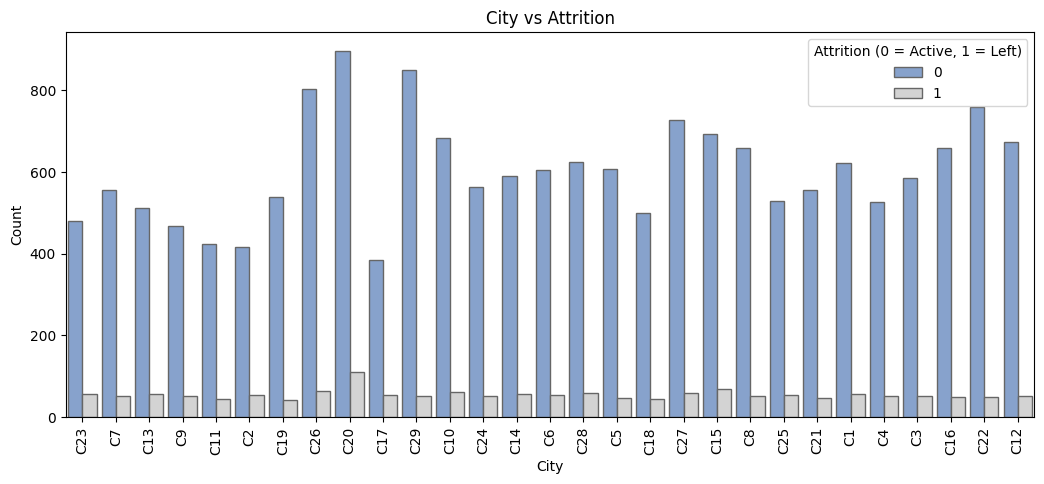

In [ ]:
plt.figure(figsize=(12.5,5))
sns.countplot(x='City', hue='attrition', data=df, palette=['#7ba0d8', 'lightgrey'], edgecolor='#666666',width=0.85)
plt.title("City vs Attrition")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.legend(title="Attrition (0 = Active, 1 = Left)")
plt.show()

- Across all cities, the number of **active drivers** (attrition = 0) consistently exceeds **those who have left** (attrition = 1), reflecting the overall **class imbalance** observed earlier.
- However, there is variation in attrition counts across cities, with some cities (e.g., those with higher overall driver counts like C20, C26, C29) also exhibiting relatively higher numbers of driver exits. This suggests that **attrition is not uniformly distributed geographically**.
- Despite this, the **proportion of attrition** appears **relatively consistent across cities**, indicating that while city influences overall driver volume, it may have a moderate rather than dominant impact on attrition when considered independently.

### **CORRELATION HEATMAP**

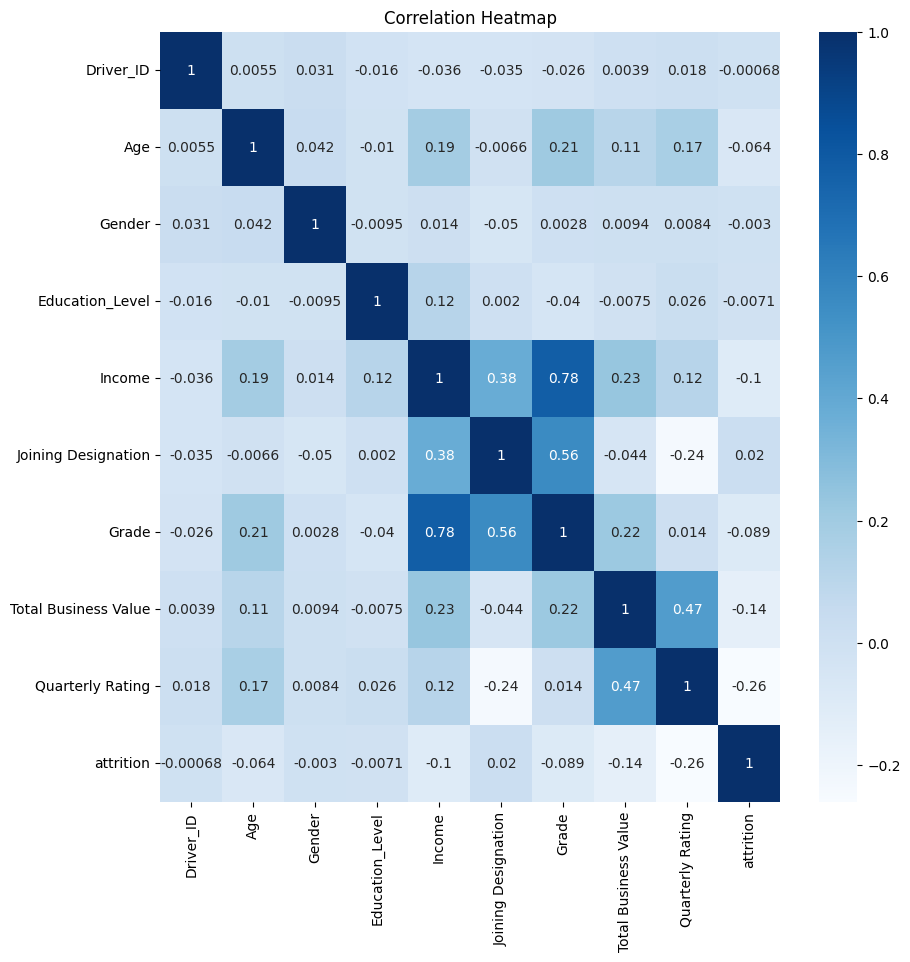

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

- The correlation heatmap indicates that **most variables have weak to moderate correlations**, suggesting **low multicollinearity** across features.
- A **strong positive correlation is observed between Income and Grade** (~ 0.78), and a **moderate correlation between Joining Designation and Grade** (~ 0.56), indicating that **higher designations and grades are associated with higher income levels**.
- **Total Business Value and Quarterly Rating** (~ 0.47) also show a **moderate positive relationship**, suggesting that better-performing drivers tend to generate higher business value.
- **With respect to the target variable (attrition), the correlations are generally weak**, with the most notable being a negative correlation with Quarterly Rating (~ -0.26) and Total Business Value (~ -0.14). This implies that **drivers with better performance and higher business contribution are less likely to leave**.
- Overall, **attrition appears to be influenced by a combination of factors rather than any single strongly correlated variable**, justifying the use of advanced models like ensemble methods.

## **DATA PREPROCESSING**


### **DUPLICATE HANDLING**


In [ ]:
df.duplicated().sum() # no duplicate entries were found in the dataset.

np.int64(0)

### **DATE FEATURE TRANSFORMATION**

In [ ]:
df['Dateofjoining'] = pd.to_datetime(df['Dateofjoining'])
df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'])
df['MMM-YY'] = pd.to_datetime(df['MMM-YY'])

/tmp/ipykernel_162/3903353595.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dateofjoining'] = pd.to_datetime(df['Dateofjoining'])
/tmp/ipykernel_162/3903353595.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'])
/tmp/ipykernel_162/3903353595.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['MMM-YY'] = pd.to_datetime(df['MMM-YY'])


- Date-related columns were converted into datetime format to enable proper time-based analysis and feature engineering.

### **DATA SORT**

In [ ]:
df = df.sort_values(by=['Driver_ID', 'MMM-YY'])

- The dataset was sorted by Driver_ID and time to preserve the chronological order of records for each driver.

### **MISSING VALUE TREATMENT**

- **KNN Imputation**

In [ ]:
# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('attrition')

# Apply KNN
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df[num_cols] = imputer.fit_transform(df[num_cols])

- Missing values in **numerical features** were imputed using **KNN Imputation**, which **estimates missing values based on similarity between observations**, thereby preserving the underlying data structure.

### **AGGREGATION**

In [ ]:
df_agg = df.groupby('Driver_ID').agg({
    'Age': 'last',
    'Gender': 'last',
    'City': 'last',
    'Education_Level': 'last',
    'Income': ['mean', 'last'],
    'Total Business Value': 'sum',
    'Quarterly Rating': ['mean', 'last'],
    'Grade': 'last',
    'attrition': 'max'}).reset_index()

In [ ]:
df_agg.head()

Driver_ID   Age Gender City Education_Level   Income           \
             last   last last            last     mean     last   
0       1.0  28.0    0.0  C23             2.0  57387.0  57387.0   
1       2.0  31.0    0.0   C7             2.0  67016.0  67016.0   
2       4.0  43.0    0.0  C13             2.0  65603.0  65603.0   
3       5.0  29.0    0.0   C9             0.0  46368.0  46368.0   
4       6.0  31.0    1.0  C11             1.0  78728.0  78728.0   

  Total Business Value Quarterly Rating      Grade attrition  
                   sum             mean last  last       max  
0            1715580.0              2.0  2.0   1.0         1  
1                  0.0              1.0  1.0   2.0         0  
2             350000.0              1.0  1.0   2.0         1  
3             120360.0              1.0  1.0   1.0         1  
4            1265000.0              1.6  2.0   3.0         0

- Since the dataset contains multiple records per driver over time, it was aggregated at the driver level to create a single consolidated record per driver.

### **FEATURE ENGINEERING**

#### **Income Increase**

In [ ]:
df['income_change'] = df.groupby('Driver_ID')['Income'].diff()

income_flag = df.groupby('Driver_ID')['income_change'].mean().reset_index()
income_flag['income_increased'] = (income_flag['income_change'] > 0).astype(int)

#### **Rating Increase**

In [ ]:
df['rating_change'] = df.groupby('Driver_ID')['Quarterly Rating'].diff()

rating_flag = df.groupby('Driver_ID')['rating_change'].mean().reset_index()
rating_flag['rating_increased'] = (rating_flag['rating_change'] > 0).astype(int)

In [ ]:
df_agg.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df_agg.columns]
df_agg.rename(columns={'Driver_ID_': 'Driver_ID'}, inplace=True)

#### **Merge back**

In [ ]:
df_agg = df_agg.merge(income_flag[['Driver_ID','income_increased']], on='Driver_ID')
df_agg = df_agg.merge(rating_flag[['Driver_ID','rating_increased']], on='Driver_ID')

- New features were engineered to capture trends in driver performance, including whether income and ratings improved over time. These features help identify behavioral patterns associated with attrition.

In [ ]:
df_agg = pd.get_dummies(df_agg, columns=['City_last', 'Education_Level_last'], drop_first=True)
df_agg = df_agg.rename(columns={'attrition_max': 'attrition'})

In [ ]:
df_agg.head()

,Driver_ID,Age_last,Gender_last,Income_mean,Income_last,Total Business Value_sum,Quarterly Rating_mean,Quarterly Rating_last,Grade_last,attrition,...,City_last_C29,City_last_C3,City_last_C4,City_last_C5,City_last_C6,City_last_C7,City_last_C8,City_last_C9,Education_Level_last_1.0,Education_Level_last_2.0
0,1.0,28.0,0.0,57387.0,57387.0,1715580.0,2.0,2.0,1.0,1,...,False,False,False,False,False,False,False,False,False,True
1,2.0,31.0,0.0,67016.0,67016.0,0.0,1.0,1.0,2.0,0,...,False,False,False,False,False,True,False,False,False,True
2,4.0,43.0,0.0,65603.0,65603.0,350000.0,1.0,1.0,2.0,1,...,False,False,False,False,False,False,False,False,False,True
3,5.0,29.0,0.0,46368.0,46368.0,120360.0,1.0,1.0,1.0,1,...,False,False,False,False,False,False,False,True,False,False
4,6.0,31.0,1.0,78728.0,78728.0,1265000.0,1.6,2.0,3.0,0,...,False,False,False,False,False,False,False,False,True,False


### **DEFINE X & y**

In [ ]:
X = df_agg.drop(['Driver_ID', 'attrition'], axis=1)
y = df_agg['attrition']

- The target variable **'attrition'** represents whether a driver has left the platform after aggregation at the driver level.

### **TRAIN-TEST SPLIT**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

- The dataset was split into training and testing sets in an 80:20 ratio. Stratified sampling was used to preserve the class distribution of the target variable.

### **HANDLE CLASS IMBALANCE (SMOTE)**

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

- Since the dataset exhibited class imbalance, SMOTE (Synthetic Minority Oversampling Technique) was applied to the training data to balance the classes and improve model performance.

### **STANDARDIZATION**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

- Feature scaling was performed using standardization to ensure that all variables contribute equally to the model and to improve model efficiency.

## **MODEL BUILDING**

### **BAGGING - RANDOM FOREST**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

- A Random Forest classifier, based on the bagging technique, was used to reduce variance and improve model stability by combining multiple decision trees.

### **BOOSTING - GRADIENT BOOSTING**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

gb.fit(X_train_res, y_train_res)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

- A Gradient Boosting classifier was applied to sequentially improve model performance by focusing on misclassified instances, thereby reducing bias.

## **MODEL EVALUATION**

### **CLASSIFICATION REPORT**

In [ ]:
from sklearn.metrics import classification_report

print("Random Forest:\n", classification_report(y_test, y_pred_rf))
print("Gradient Boosting:\n", classification_report(y_test, y_pred_gb))

Random Forest:
               precision    recall  f1-score   support

           0       0.74      0.66      0.70       153
           1       0.85      0.89      0.87       324

    accuracy                           0.82       477
   macro avg       0.79      0.77      0.78       477
weighted avg       0.81      0.82      0.81       477

Gradient Boosting:
               precision    recall  f1-score   support

           0       0.74      0.64      0.69       153
           1       0.84      0.90      0.87       324

    accuracy                           0.81       477
   macro avg       0.79      0.77      0.78       477
weighted avg       0.81      0.81      0.81       477



Both models demonstrate good predictive performance, with **accuracy of about 81–82%**.

1.  **Random Forest**
- Accuracy: 82%
- Better recall for class 0 (active drivers) → 0.66
- Strong performance for attrition class (F1 ≈ 0.87)
2.  **Gradient Boosting**
- Accuracy: 81%
- Higher recall for attrition (class 1) → 0.90
- Slightly better at identifying drivers who will leave

### **ROC-AUC SCORE**

In [ ]:
from sklearn.metrics import roc_auc_score

print("RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("GB ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

RF ROC-AUC: 0.8355725006051804
GB ROC-AUC: 0.8366819979020415


- **Random Forest: 0.836**
- **Gradient Boosting: 0.837**

Both models show **strong discriminative ability** (**AUC>0.83**), indicating good separation between drivers who leave
& those who stay.

### **ROC CURVE**

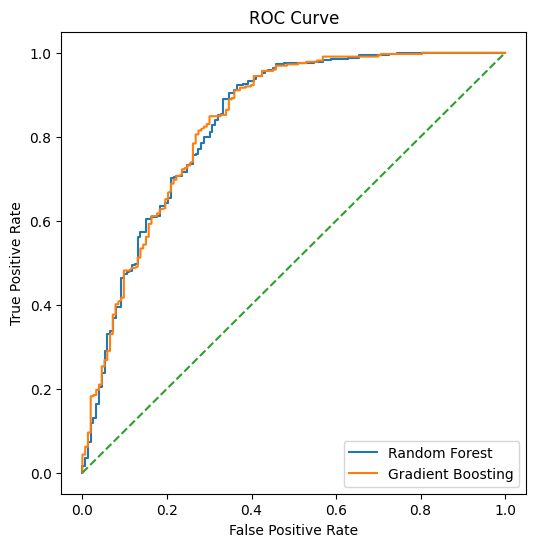

In [ ]:
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.figure(figsize=(6,6))
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot(fpr_gb, tpr_gb, label='Gradient Boosting')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

- The ROC curves for both models are **closely overlapping**, suggesting comparable performance.

## **MODEL COMPARISON**

1.  **Random Forest**
- Better balance overall
- Slightly better for identifying active drivers

2.  **Gradient Boosting**
- Better at identifying drivers likely to leave (higher recall)
- More suitable for business use-case

Since attrition prediction focuses on identifying drivers who may leave, **Gradient Boosting is the preferred model.**

## **KEY BUSINESS INSIGHTS**

- Low income drivers are more likely to leave
- Drivers with low ratings (especially rating = 1) show highest attrition
- Drivers generating low or near-zero business value are at high risk
- Attrition is not strongly dependent on demographics, but more on performance metrics
-  Income, rating, and business value together form the strongest predictors

## **ACTIONABLE RECOMMENDATIONS**

**1. INCOME STABILIZATION**
- Introduce minimum guaranteed earnings  
- Reduce income volatility to improve driver retention.
---
**2. PERFORMANCE INCENTIVES**
- Reward drivers with improving ratings
- Introduce bonus structures for consistent performance
---
**3. EARLY WARNING SYSTEM**
- Use the model to flag high-risk drivers
- Intervene with incentives, support calls, personalized engagement
---
**4. CITY-LEVEL STRATEGY**
- Monitor cities with relatively higher attrition
- Improve local driver support & demand matching
---
**5. FOCUS ON LOW PERFORMERS**
- Provide training/support to drivers with low ratings, low business value
- Implement performance improvement programs with mentorship, feedback, and periodic evaluation to enhance driver performance.
---

The study demonstrates that **driver attrition can be effectively predicted using machine learning models, particularly ensemble techniques**. Among the models tested, **Gradient Boosting performs slightly better**, especially in identifying drivers at risk of leaving.

By leveraging these insights, Ola can implement data-driven retention strategies, reduce churn, and optimize operational efficiency.

---
---
---